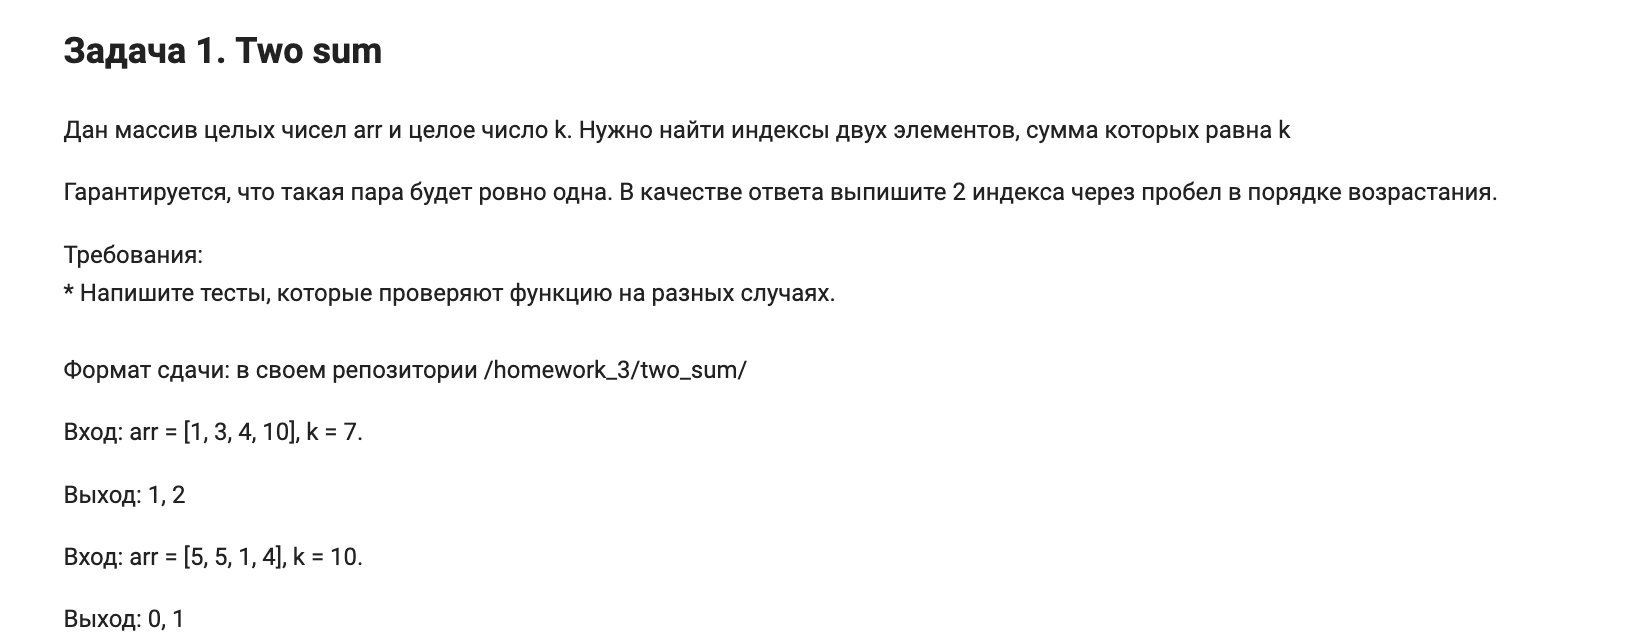

## Ход решения

- Заводим пустой словарь `seen`. В нём будем хранить уже просмотренные элементы массива в формате `значение: индекс`.

- Идём по массиву `arr` слева направо по индексам `i`.

- Для текущего элемента `x = arr[i]` вычисляем число, которого не хватает до суммы `k`:

  `need = k - x`

- Проверяем, есть ли `need` среди уже просмотренных элементов:
  - если `need in seen`, то пара найдена;
  - индекс первого элемента равен `seen[need]`, индекс второго — `i`;
  - сразу возвращаем эти два индекса.

- Если нужного числа ещё нет, сохраняем текущий элемент: `seen[x] = i`.

Проверка выполняется **до** добавления текущего элемента в `seen`. Благодаря этому один и тот же элемент массива нельзя использовать дважды. Например, при `x = 5` и `k = 10` первый `5` сначала сохраняется, а второй `5` уже находит его в словаре.

Так как в `seen` находятся только элементы, расположенные левее текущего, `seen[need] < i`, поэтому индексы сразу возвращаются в порядке возрастания.

## Сложность алгоритма

Пусть `n = len(arr)`.

Мы проходим по массиву один раз. Поиск элемента в словаре и добавление в словарь в среднем работают за `O(1)`.

| Что | Сложность |
| --- | ---: |
| Время | `O(n)` |
| Доп. память | `O(n)` |

В худшем случае перед нахождением пары в словаре может находиться почти весь массив.

# Реализация

Реализуем функцию `two_sum`.

По условию подходящая пара существует ровно одна, поэтому после нахождения пары можно сразу вернуть ответ.

In [1]:
def two_sum(arr, k):
    seen = {}

    for i in range(len(arr)):
        x = arr[i]
        need = k - x

        if need in seen:
            return seen[need], i

        seen[x] = i

# Визуализация работы алгоритма

Рассмотрим пример из условия:

```text
arr = [1, 3, 4, 10]
k = 7
```

| Шаг | `i` | `x = arr[i]` | `need = k - x` | `seen` до проверки | Результат |
| ---: | ---: | ---: | ---: | --- | --- |
| 1 | 0 | 1 | 6 | `{}` | `6` нет → сохраняем `1: 0` |
| 2 | 1 | 3 | 4 | `{1: 0}` | `4` нет → сохраняем `3: 1` |
| 3 | 2 | 4 | 3 | `{1: 0, 3: 1}` | `3` найден по индексу `1` |

На третьем шаге получаем:

```text
arr[1] + arr[2] = 3 + 4 = 7
```

Поэтому функция возвращает:

```text
(1, 2)
```

Для второго примера `arr = [5, 5, 1, 4]`, `k = 10` первый `5` сохраняется как `5: 0`, а на следующем шаге второй `5` находит его в `seen`. Ответ — `(0, 1)`.

# Тесты

Тесты проверяют:

- оба примера из условия;
- отрицательные числа;
- наличие нуля;
- пару на краях массива;
- случай, когда нельзя использовать один элемент дважды;
- большой вход из `100_000` элементов.

In [2]:
assert two_sum([1, 3, 4, 10], 7) == (1, 2)
assert two_sum([5, 5, 1, 4], 10) == (0, 1)
assert two_sum([-3, 4, 7, 11], 4) == (0, 2)
assert two_sum([0, 4, 2], 2) == (0, 2)
assert two_sum([2, 7, 10, 3], 5) == (0, 3)
assert two_sum([3, 2, 4], 6) == (1, 2)

arr = list(range(100_000))
assert two_sum(arr, 199_997) == (99_998, 99_999)

print("Все тесты пройдены")

Все тесты пройдены
